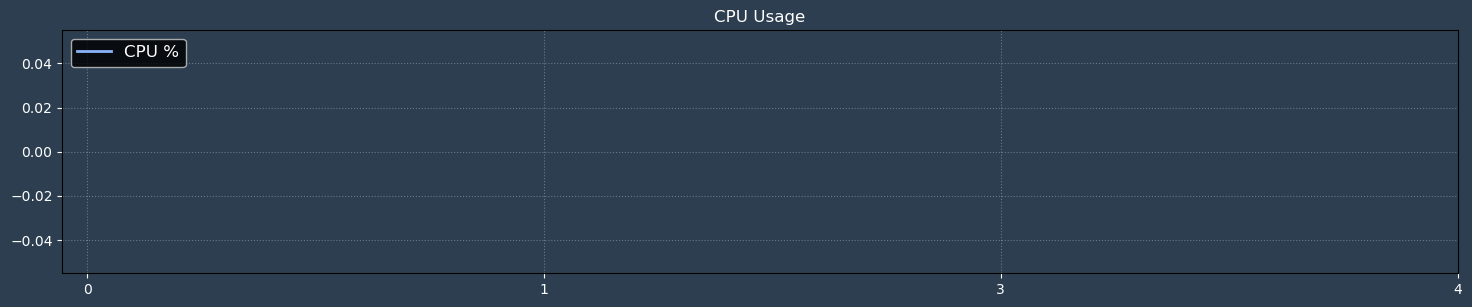

In [1]:
import tkinter as tk
from tkinter import ttk, messagebox
import psutil
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import time
import logging
from datetime import datetime

# Configure logging
logging.basicConfig(
    filename='system_monitor.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

class SystemMonitorApp:
    def __init__(self, root):
        self.root = root
        self.root.title("System Monitor")
        self.root.geometry("1000x800")

        # Theme configuration
        self.is_dark_theme = True
        self.themes = {
            'dark': {
                'bg': '#221e2f',
                'fg': '#e0e0e0',
                'frame_bg': '#181821',
                'accent': '#8ab4f8'
            },
            'light': {
                'bg': '#f5f7fa',
                'fg': '#2e2e2e',
                'frame_bg': '#ffffff',
                'accent': '#1a73e8'
            }
        }
        self.current_theme = self.themes['dark']
        self.root.configure(bg=self.current_theme['bg'])

        # Data storage
        self.timestamps = []
        self.cpu_data = []
        self.memory_data = []
        self.disk_data = []
        self.network_sent_speed = []
        self.network_received_speed = []

        self.start_time = None
        self.last_net_io_main = psutil.net_io_counters()
        self.last_net_io_widget = psutil.net_io_counters()
        self.update_interval = 1500  # milliseconds

        self.graph_option = tk.StringVar(value="CPU Usage")
        self.search_var = tk.StringVar()

        # Widget variables for dragging
        self.widget_x = 0
        self.widget_y = 0

        # Store process item ids for efficient updating
        self.process_items = {}

        self.setup_ui()
        self.setup_styles()
        self.update_data()
        self.root.after(6000, self.cleanup_old_data)

    def setup_styles(self):
        # Set up styles once
        style = ttk.Style()
        style.theme_use("clam")
        style.configure("Treeview", font=("Segoe UI", 14))
        style.configure("Treeview.Heading", font=("Segoe UI", 15, "bold"))
        style.configure("TLabel", font=("Segoe UI", 13))
        style.configure("TButton", font=("Segoe UI", 13))
        style.configure("TEntry", font=("Segoe UI", 13))
        style.configure("TMenubutton", font=("Segoe UI", 13))
        self.update_theme()

    def setup_ui(self):
        main_frame = ttk.Frame(self.root, padding="12 12 12 12")
        main_frame.pack(fill=tk.BOTH, expand=True, padx=15, pady=10)

        controls_frame = ttk.Frame(main_frame)
        controls_frame.pack(fill=tk.X, pady=(0, 10))

        self.theme_btn = ttk.Button(
            controls_frame, text="Toggle Theme", command=self.toggle_theme
        )
        self.theme_btn.pack(side=tk.LEFT, padx=5)

        self.widget_btn = ttk.Button(
            controls_frame, text="Toggle Widget Mode", command=self.toggle_widget_mode
        )
        self.widget_btn.pack(side=tk.LEFT, padx=5)

        search_frame = ttk.Frame(controls_frame)
        search_frame.pack(side=tk.RIGHT, padx=10, pady=5, anchor='ne')
        ttk.Label(search_frame, text="Search:").pack(side=tk.LEFT)
        self.search_entry = ttk.Entry(search_frame, textvariable=self.search_var, width=20)
        self.search_entry.pack(side=tk.LEFT)
        self.search_var.trace_add('write', self.filter_processes)

        info_frame = ttk.Frame(main_frame)
        info_frame.pack(fill=tk.X)
        self.cpu_label = ttk.Label(info_frame, text="CPU Usage: 0.0%")
        self.cpu_label.pack(anchor=tk.W)
        self.memory_label = ttk.Label(info_frame, text="Memory Usage: 0.0%")
        self.memory_label.pack(anchor=tk.W)
        self.disk_label = ttk.Label(info_frame, text="Disk Space Usage: 0.0%")
        self.disk_label.pack(anchor=tk.W)
        self.network_label = ttk.Label(info_frame, text="Network: ↑ 0.00 MB/s, ↓ 0.00 MB/s")
        self.network_label.pack(anchor=tk.W)

        dropdown_frame = ttk.Frame(main_frame)
        dropdown_frame.pack(pady=5, anchor=tk.W)
        ttk.Label(dropdown_frame, text="Select Graph:").pack(side=tk.LEFT)
        options = ["CPU Usage", "Memory Usage", "Disk Space Usage", "Network Speed"]
        ttk.OptionMenu(
            dropdown_frame, self.graph_option, options[0], *options, command=self.update_graphs
        ).pack(side=tk.LEFT, padx=5)

        self.fig, self.ax = plt.subplots(figsize=(9, 3), dpi=100)
        self.canvas = FigureCanvasTkAgg(self.fig, master=main_frame)
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True, pady=5)

        self.process_tree = ttk.Treeview(
            main_frame,
            columns=("PID", "Name", "CPU", "Memory"),
            show="headings",
            height=10
        )
        for col in ("PID", "Name", "CPU", "Memory"):
            self.process_tree.heading(col, text=col, command=lambda c=col: self.sort_processes(c))
            self.process_tree.column(col, anchor=tk.CENTER)
        self.process_tree.pack(fill=tk.BOTH, expand=True, pady=10)

        self.context_menu = tk.Menu(self.root, tearoff=0)
        self.context_menu.add_command(label="Show Details", command=self.show_process_details)
        self.context_menu.add_command(label="Terminate Process", command=self.terminate_process)
        self.process_tree.bind("<Button-3>", self.show_context_menu)

        button_frame = ttk.Frame(main_frame)
        button_frame.pack(fill=tk.X, pady=5)
        terminate_btn = ttk.Button(
            button_frame, text="Terminate Selected Process", command=self.terminate_process
        )
        terminate_btn.pack(side=tk.LEFT, padx=5)

        self.status_bar = ttk.Label(
            main_frame, text="Ready", relief=tk.SUNKEN, anchor=tk.W
        )
        self.status_bar.pack(fill=tk.X, side=tk.BOTTOM, pady=(5, 0))

    def update_theme(self):
        style = ttk.Style()
        style.configure(
            "TFrame", background=self.current_theme['frame_bg']
        )
        style.configure(
            "TLabel", background=self.current_theme['frame_bg'],
            foreground=self.current_theme['fg']
        )
        style.configure(
            "Treeview", background=self.current_theme['bg'],
            foreground=self.current_theme['fg'],
            fieldbackground=self.current_theme['bg']
        )
        style.configure(
            "Treeview.Heading", font=("Segoe UI", 15, "bold")
        )
        style.map(
            'Treeview', background=[('selected', self.current_theme['accent'])]
        )
        style.configure("TButton", font=("Segoe UI", 13))
        style.configure("TEntry", font=("Segoe UI", 13))
        style.configure("TMenubutton", font=("Segoe UI", 13))

    def toggle_theme(self):
        self.is_dark_theme = not self.is_dark_theme
        self.current_theme = self.themes['dark' if self.is_dark_theme else 'light']
        self.update_theme()
        self.root.configure(bg=self.current_theme['bg'])
        plt.style.use('dark_background' if self.is_dark_theme else 'default')
        self.update_graphs()

    def show_context_menu(self, event):
        try:
            self.process_tree.selection_set(self.process_tree.identify_row(event.y))
            self.context_menu.tk_popup(event.x_root, event.y_root)
        finally:
            self.context_menu.grab_release()

    def show_process_details(self):
        selected_item = self.process_tree.focus()
        if not selected_item:
            messagebox.showwarning("No selection", "Please select a process to view details.", icon='warning', parent=self.root)
            return
        values = self.process_tree.item(selected_item, 'values')
        pid = int(values[0])
        try:
            proc = psutil.Process(pid)
            details = (
                f"Process Details:\n"
                f"PID: {pid}\n"
                f"Name: {proc.name()}\n"
                f"Status: {proc.status()}\n"
                f"CPU Percent: {proc.cpu_percent(interval=0.2)/psutil.cpu_count(logical=True):.2f}%\n"
                f"Memory Percent: {proc.memory_percent():.1f}%\n"
                f"Create Time: {datetime.fromtimestamp(proc.create_time()).strftime('%Y-%m-%d %H:%M:%S')}\n"
                f"Threads: {proc.num_threads()}\n"
            )
            self.show_custom_dialog("Process Details", details)
        except Exception as e:
            logging.error(f"Error showing process details: {str(e)}")
            # Only show popup for critical errors
            if isinstance(e, psutil.NoSuchProcess):
                messagebox.showerror("Error", f"Failed to get process details.\n{str(e)}", parent=self.root)

    def show_custom_dialog(self, title, message):
        dialog = tk.Toplevel(self.root)
        dialog.title(title)
        dialog.grab_set()
        dialog.transient(self.root)
        dialog.resizable(False, False)
        dialog.configure(bg=self.current_theme['bg'])
        label = tk.Label(dialog, text=message, font=("Segoe UI", 14), bg=self.current_theme['bg'], fg=self.current_theme['fg'], justify="left", anchor="w")
        label.pack(padx=30, pady=20)
        button = tk.Button(dialog, text="OK", font=("Segoe UI", 14), command=dialog.destroy)
        button.pack(pady=(0, 20))
        dialog.update_idletasks()
        w = dialog.winfo_reqwidth()
        h = dialog.winfo_reqheight()
        ws = dialog.winfo_screenwidth()
        hs = dialog.winfo_screenheight()
        x = (ws // 2) - (w // 2)
        y = (hs // 2) - (h // 2)
        dialog.geometry(f'{w}x{h}+{x}+{y}')

    def sort_processes(self, column):
        items = [(self.process_tree.set(k, column), k) for k in self.process_tree.get_children('')]
        items.sort(reverse=True)
        for index, (val, k) in enumerate(items):
            self.process_tree.move(k, '', index)

    def filter_processes(self, *args):
        search_term = self.search_var.get().lower()
        for item in self.process_tree.get_children():
            values = self.process_tree.item(item)['values']
            if any(search_term in str(value).lower() for value in values):
                self.process_tree.item(item, tags='match')
            else:
                self.process_tree.item(item, tags='nomatch')
        self.process_tree.tag_configure('match', background=self.current_theme['accent'])
        self.process_tree.tag_configure('nomatch', background=self.current_theme['bg'])

    def update_status(self, message):
        self.status_bar.config(text=f"Last update: {datetime.now().strftime('%H:%M:%S')} - {message}")

    def update_data(self):
        try:
            if self.start_time is None:
                self.start_time = time.time()
            elapsed_time = int(time.time() - self.start_time)
            self.timestamps.append(str(elapsed_time))

            cpu_usage = psutil.cpu_percent()
            memory_usage = psutil.virtual_memory().percent
            disk_space_usage = psutil.disk_usage('/').percent

            current_net_io = psutil.net_io_counters()
            sent_speed = (current_net_io.bytes_sent - self.last_net_io_main.bytes_sent) / (1024 * 1024)
            recv_speed = (current_net_io.bytes_recv - self.last_net_io_main.bytes_recv) / (1024 * 1024)
            self.last_net_io_main = current_net_io

            self.cpu_data.append(cpu_usage)
            self.memory_data.append(memory_usage)
            self.disk_data.append(disk_space_usage)
            self.network_sent_speed.append(sent_speed)
            self.network_received_speed.append(recv_speed)

            self.cpu_label.config(text=f"CPU Usage: {cpu_usage:.1f}%")
            self.memory_label.config(text=f"Memory Usage: {memory_usage:.1f}%")
            self.disk_label.config(text=f"Disk Space Usage: {disk_space_usage:.1f}%")
            self.network_label.config(text=f"Network: ↑ {sent_speed:.2f} MB/s, ↓ {recv_speed:.2f} MB/s")

            self.update_graphs()
            self.update_process_list()
            self.update_status("Data updated successfully")
        except Exception as e:
            logging.error(f"Error updating data: {str(e)}")
            self.update_status(f"Error: {str(e)}")
        self.root.after(self.update_interval, self.update_data)

    def cleanup_old_data(self):
        try:
            max_points = 60
            while len(self.timestamps) > max_points:
                self.timestamps.pop(0)
                self.cpu_data.pop(0)
                self.memory_data.pop(0)
                self.disk_data.pop(0)
                self.network_sent_speed.pop(0)
                self.network_received_speed.pop(0)
        except Exception as e:
            logging.error(f"Error cleaning up data: {str(e)}")
        self.root.after(6000, self.cleanup_old_data)

    def update_graphs(self, *_):
        try:
            self.ax.clear()
            selected = self.graph_option.get()
            max_points = 60
            time_labels = self.timestamps[-max_points:]
            show_every = max(1, len(time_labels) // 6)
            x_ticks = range(0, len(time_labels), show_every)
            x_labels = [time_labels[i] for i in x_ticks]
            bg_color = '#2c3e50' if self.is_dark_theme else '#ffffff'
            fg_color = 'white' if self.is_dark_theme else 'black'
            self.fig.patch.set_facecolor(bg_color)
            self.ax.set_facecolor(bg_color)
            self.ax.tick_params(axis='both', colors=fg_color, labelsize=10)
            self.ax.title.set_color(fg_color)
            self.ax.grid(True, linestyle=':', alpha=0.3, color=fg_color)
            if selected == "CPU Usage":
                self.ax.plot(self.cpu_data[-max_points:], label="CPU %", color=self.current_theme['accent'], linewidth=2)
            elif selected == "Memory Usage":
                self.ax.plot(self.memory_data[-max_points:], label="Memory %", color='orange', linewidth=2)
            elif selected == "Disk Space Usage":
                self.ax.plot(self.disk_data[-max_points:], label="Disk %", color='green', linewidth=2)
            elif selected == "Network Speed":
                self.ax.plot(self.network_sent_speed[-max_points:], label="Sent (MB/s)", color='red', linewidth=2)
                self.ax.plot(self.network_received_speed[-max_points:], label="Received (MB/s)", color='blue', linewidth=2)
            self.ax.set_xticks(x_ticks)
            self.ax.set_xticklabels(x_labels)
            self.ax.set_title(selected)
            self.ax.legend(loc='upper left', fontsize=12)
            self.fig.tight_layout()
            self.canvas.draw()
        except Exception as e:
            logging.error(f"Error updating graphs: {str(e)}")
            self.update_status(f"Error updating graphs: {str(e)}")

    def update_process_list(self):
        try:
            num_cpus = psutil.cpu_count(logical=True)
            # Build a dict of current processes
            processes = {}
            for proc in psutil.process_iter(['pid', 'name', 'cpu_percent', 'memory_percent']):
                try:
                    processes[proc.info['pid']] = proc.info
                except (psutil.NoSuchProcess, psutil.AccessDenied):
                    continue
            # Only show top 10 by CPU
            top = sorted(processes.values(), key=lambda x: x['cpu_percent'], reverse=True)[:10]
            top_pids = set(proc['pid'] for proc in top)

            # Update or insert rows
            existing_pids = set()
            for item in self.process_tree.get_children():
                pid = int(self.process_tree.item(item, 'values')[0])
                if pid in top_pids:
                    proc = processes[pid]
                    norm_cpu = proc['cpu_percent'] / num_cpus
                    self.process_tree.item(item, values=(
                        proc['pid'],
                        proc['name'][:20],
                        f"{norm_cpu:.1f}",
                        f"{proc['memory_percent']:.1f}"
                    ))
                    existing_pids.add(pid)
                else:
                    self.process_tree.delete(item)

            # Insert new rows for processes not already in Treeview
            for proc in top:
                if proc['pid'] not in existing_pids:
                    norm_cpu = proc['cpu_percent'] / num_cpus
                    self.process_tree.insert("", tk.END, values=(
                        proc['pid'],
                        proc['name'][:20],
                        f"{norm_cpu:.1f}",
                        f"{proc['memory_percent']:.1f}"
                    ))
        except Exception as e:
            logging.error(f"Error updating process list: {str(e)}")
            self.update_status(f"Error updating process list: {str(e)}")

    def terminate_process(self):
        selected_item = self.process_tree.focus()
        if not selected_item:
            messagebox.showwarning("No selection", "Please select a process to terminate.", icon='warning', parent=self.root)
            return
        values = self.process_tree.item(selected_item, 'values')
        pid = int(values[0])
        try:
            proc = psutil.Process(pid)
            if messagebox.askyesno("Confirm", f"Are you sure you want to terminate process {pid} ({proc.name()})?", parent=self.root):
                proc.terminate()
                proc.wait(timeout=3)
                logging.info(f"Process {pid} terminated successfully")
                messagebox.showinfo("Success", f"Process {pid} terminated successfully.", parent=self.root)
                self.update_status(f"Process {pid} terminated")
        except Exception as e:
            logging.error(f"Error terminating process {pid}: {str(e)}")
            messagebox.showerror("Error", f"Failed to terminate process {pid}.\n{str(e)}", parent=self.root)

    def create_widget_mode(self):
        self.widget_window = tk.Toplevel(self.root)
        self.widget_window.title("System Monitor Widget")
        self.widget_window.geometry("650x70")
        self.widget_window.attributes("-topmost", True)
        self.widget_window.resizable(False, False)
        self.widget_window.configure(bg="black")
        self.widget_window.overrideredirect(True)
        close_btn = tk.Button(
            self.widget_window, text="×", width=3, command=self.toggle_widget_mode,
            bg="#FF5522", fg="#FFFFFF", borderwidth=1, relief="solid",
            highlightthickness=0, font=("Segoe UI", 14, "bold")
        )
        close_btn.place(x=600, y=2)
        self.widget_window.bind('<Button-1>', self.start_move)
        self.widget_window.bind('<B1-Motion>', self.on_move)
        font_style = ("Segoe UI", 12, "bold")
        label_fg = "#CCCCCC"
        self.widget_cpu_label = tk.Label(
            self.widget_window, text="CPU: 0.0%", bg="black", fg=label_fg, font=font_style
        )
        self.widget_cpu_label.place(x=20, y=20)
        self.widget_memory_label = tk.Label(
            self.widget_window, text="Memory: 0.0%", bg="black", fg=label_fg, font=font_style
        )
        self.widget_memory_label.place(x=120, y=20)
        self.widget_disk_label = tk.Label(
            self.widget_window, text="Disk: 0.0%", bg="black", fg=label_fg, font=font_style
        )
        self.widget_disk_label.place(x=260, y=20)
        self.widget_network_label = tk.Label(
            self.widget_window, text="Net: ↑ 0.00 MB/s ↓ 0.00 MB/s", bg="black", fg=label_fg, font=font_style
        )
        self.widget_network_label.place(x=360, y=20)
        self.update_widget_data()

    def start_move(self, event):
        self.widget_x = event.x
        self.widget_y = event.y

    def on_move(self, event):
        deltax = event.x - self.widget_x
        deltay = event.y - self.widget_y
        x = self.widget_window.winfo_x() + deltax
        y = self.widget_window.winfo_y() + deltay
        self.widget_window.geometry(f"+{x}+{y}")

    def update_widget_data(self):
        try:
            if hasattr(self, 'widget_window') and self.widget_window.winfo_exists():
                cpu_usage = psutil.cpu_percent()
                memory_usage = psutil.virtual_memory().percent
                disk_space_usage = psutil.disk_usage('/').percent
                current_net_io = psutil.net_io_counters()
                widget_sent_speed = (current_net_io.bytes_sent - self.last_net_io_widget.bytes_sent) / (1024 * 1024)
                widget_recv_speed = (current_net_io.bytes_recv - self.last_net_io_widget.bytes_recv) / (1024 * 1024)
                self.last_net_io_widget = current_net_io
                self.widget_cpu_label.config(text=f"CPU: {cpu_usage:.1f}%")
                self.widget_memory_label.config(text=f"Memory: {memory_usage:.1f}%")
                self.widget_disk_label.config(text=f"Disk: {disk_space_usage:.1f}%")
                self.widget_network_label.config(text=f"Net: ↑ {widget_sent_speed:.2f} MB/s ↓ {widget_recv_speed:.2f} MB/s")
                self.widget_window.after(self.update_interval, self.update_widget_data)
        except Exception as e:
            logging.error(f"Error updating widget data: {str(e)}")

    def toggle_widget_mode(self):
        if hasattr(self, 'widget_window') and self.widget_window.winfo_exists():
            self.widget_window.destroy()
            self.root.deiconify()
            self.root.lift()
        else:
            self.create_widget_mode()
            self.root.iconify()

if __name__ == "__main__":
    try:
        root = tk.Tk()
        app = SystemMonitorApp(root)
        root.mainloop()
    except Exception as e:
        logging.critical(f"Application crashed: {str(e)}")
        messagebox.showerror("Fatal Error", f"The application has crashed.\n{str(e)}")
